In [26]:
import numpy as np
from numpy import linalg
import matplotlib.pyplot as plt
import math
import cmath
import scipy
import scipy.interpolate as interpolate
import scipy.integrate as integrate
import scipy.special as special
from scipy.fft import fft, ifft
import numpy.ma as ma
import time
#np.set_printoptions(threshold=sys.maxsize)
pts = 5000 # number of iterator steps where neccessary
H_to_K = 1/0.000003166808534191 # conversion of Hartrees to Kelvin
H_to_GHz = 6579689.74479021 # conversion of Hartrees to GigaHertz

tol1 = 1.2e-15 # tolerance where neccessary

tol2 = 1

# When changing $C_6$, we must ensure that the following are kept the same
## Excited bound states
## potential depth
## scattering length range
## Omega freqeuncy range


# $r_6 = \frac{2\mu C_6}{\hbar^2}^{1/4}$

In [31]:
R1 = 3.5 # starting posistion r1 in a0
R2 = 1300 # ending posistion r2 in a0
dr1 = 0.1 # step spacing in a0

N_big = int((R2-R1)/dr1)
print(N_big)
ipap_big = np.arange(1,N_big, 1.0)
R_grid = R1 + dr1*ipap_big


Eo = 3.166808534191e-12 # inital particle energy, 1uK in Hartrees
me = 9.1093837e-28 # electron mass in grams
mNa_g = 3.8175458e-23 # sodium mass in grams
mK_g = 6.4924249e-23 # potassium mass in grams
mNaK_g = mNa_g + mK_g # sodium potassium mass in grams
mNak = mNaK_g/me # sodium potassium mass in au
mu = (mNak**2)/(2*mNak) # reduced mass of sodium potassium 
hbar = 1.0546e-27 # reduced Planck constant in cgs
e = 4.8032e-10 # electron charge in cgs
ao = (hbar**2)/(me*e**2) # Bohr radius in cgs
d_NaK = 1.07 # dipole moment for NaK in a.m.u.
gamma = 0.1
I = cmath.sqrt(-1)

12965


In [33]:
C12_1 = 3.6e10 # C12 coefficient in Eh*ao
C6_list = np.linspace((3.3e-2)*2e5, 2e5, 5) # C6 coefficient list in Eh*a0^6

VLJ_1 = (C12_1/(R_grid**12)) - (C6_list[0]/(R_grid**6)) # standard Lennard-Jones interatomic potential




In [35]:
print(C6_list)

[  6600.  54950. 103300. 151650. 200000.]


In [37]:
for i in range(len(VLJ_1)):
    if abs(abs(VLJ_1[i]) - Eo) < tol1:
        print(i)
        print(VLJ_1[i])
        break

print(R_grid[4410])

3538
-3.1667708993279674e-12
444.6


In [39]:
def Numerov(Energy, Num, V_r, dr, grid): # function to find psi(r) continuum state (E>0)
    psi = np.zeros_like(grid)
    psi[0] = 0 # impose boundary condition psi(0) = 0
    psi[1] = dr # let psi(1) = the spacing length
    #print(f' psi[1] = {psi[1]}')
    ksq = 2*mu*(Energy - V_r) # wave number squared for the energy
    ksq_p = 2*mu*Energy
    #print(max(ksq))

    for i in range(2,Num):  # Numerov Algorithm, range is 2 -> N since psi(0), psi(1) already set
        #if i < 100:
       #     print(f' first term in numerator is {(2*(1 - (5/12)*(dr**2)*ksq[i-1])*psi[i-1])}')
        #    print(f' the numerator is {((2*(1 - (5/12)*(dr**2)*ksq[i-1])*psi[i-1]) - ((1 + (1/12)*(dr**2)*ksq[i-2])*psi[i-2]))}')
        psi[i] = ((2*(1 - (5/12)*(dr**2)*ksq[i-1])*psi[i-1]) - ((1 + (1/12)*(dr**2)*ksq[i-2])*psi[i-2]))/(1 + (1/12)*(dr**2)*ksq[i])
        psi = psi/max(psi)
       # if i == int(0.5*Num):
       #     print('halfway there')
       # if i == int(0.9*Num):
       #     print('almost there')
    
    Psi_f = psi/max(psi) # divide Psi by its largest value to qvoid it becoming too large
    Psi_prime = np.gradient(Psi_f, grid) # find the derivate over the grid r
    
    # Energy Normalization
    A_term = Psi_f[-1]**2
    B_term = Psi_prime[-1]**2
    B_coef = 1/(ksq[-1])
    U_sq = A_term + B_coef*B_term
    U = np.sqrt(U_sq)
    norm_factor = np.sqrt((2*mu)*(1/(np.pi*np.sqrt(ksq_p))))
    #print((U,norm_factor))
    
    Psi_Energy_Normalized = (1/U)*(Psi_f)*norm_factor
    
        
    return Psi_Energy_Normalized

In [41]:
min_v = min(VLJ_1)
print(f' min of VLJ = {min_v*H_to_K} K')
K_max = np.sqrt(2*mu*(Eo - min_v))
lambda_min = (2*np.pi)/K_max

print(f' smallest deBroglie wavelength = {lambda_min} ao')
print(N_big-1)
psi = np.zeros(N_big-1)  # initializing psi(r) as array of zeros
Psi_1 = Numerov(Eo, N_big-1, VLJ_1, dr1, R_grid) # wave function Psi

 min of VLJ = -95.52114453296394 K
 smallest deBroglie wavelength = 1.073828648480578 ao
12964


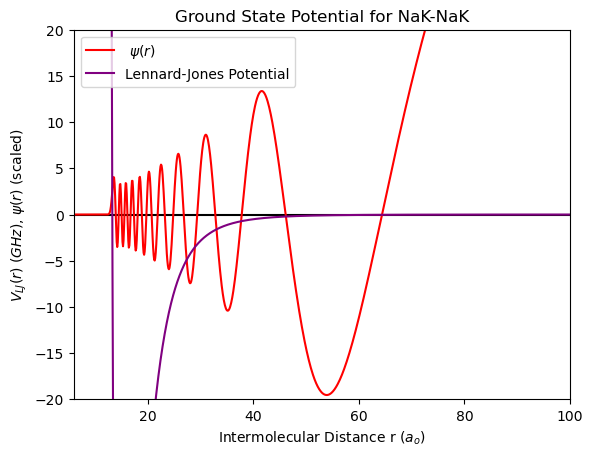

In [42]:
plt.hlines(0,0, R_grid[-1], color = 'black')
#psi_1prime = np.gradient(Psi_1, r) # first posistion derivate of wave function Psi
plt.plot(R_grid, 1e-1*Psi_1, label = f' $\\psi(r)$', color = 'red') 
#plt.plot(r, Vr*1e0, label = 'Scaled Lennard-Jones Potential', color = 'purple')
#plt.xlabel('$ interatomic$ $distance$ $r$ $(a_{o})$')
#plt.ylabel('$\\psi(r)$ ($\\frac{1}{\\sqrt{a_{o}}}$)')

plt.plot(R_grid, VLJ_1*H_to_K, color = 'purple', label = 'Lennard-Jones Potential')
#plt.xlim(R1,R2+100)
plt.xlim(6,100)
#plt.ylim(min_v + 0.2*min_v, 0.1*abs(min_v))
plt.ylim(-20, 20)
#plt.ylim(-1e-12, 1e-12)
plt.ylabel('$V_{LJ}(r)$ $(GHz)$, $\\psi(r)$ (scaled)')
plt.xlabel('Intermolecular Distance r $(a_o)$')
plt.title('Ground State Potential for NaK-NaK')
plt.legend()

In [43]:
#r1_i = 1898 # index of r1 in larger grid
r1_i = 50# index of r1 in larger grid
#r2_i = 17875 # index of r2 in larger grid
r2_i = 4700 # index of r2 in larger grid

r1 = round(R_grid[r1_i],5) # ~10ao, smaller grid starting posistion
r2 = round(R_grid[r2_i],5) # ~300ao, larger grid ending posistion
print((r1, r2))

N_small = int((r2 - r1)/dr1) # number of points in smaller grid
ipap_p = np.arange(1,N_small, 1.0) # DVR paper indexing for smaller grid
r_grid = r1 + dr1*ipap_p # sub grid to calculate DVR and FC factor on

(8.6, 473.6)


In [44]:
def Hamiltonian_DVR(a, b, dx, C6_coef, KE_matrix): # DVR method for finding bound states
    N = int((b-a)/dx) # Number of grid points
    ipaper = np.arange(1,N, 1.0) # indexing from the paper, given i = 1,2,...,N-1
    x = a + dx*ipaper # grid from paper
    for i in range(100):
        rand1 = np.random.rand()
        rand2 = np.random.rand()
        rand3 = np.random.rand()

        Theta_A = np.arccos(1 - 2*rand1)
        Theta_B = np.arccos(1 - 2*rand2)
        PHI = 2*np.pi*rand3
        C_3_coef = ((d_NaK)**2)*(np.sin(Theta_A)*np.sin(Theta_B)*np.cos(PHI) - 2*np.cos(Theta_A)*np.cos(Theta_B))
        if C_3_coef > 0:
            break
    V_dip_dip = (C_3_coef)/(x**3)
    Vx = C6_coef/(x**6) - V_dip_dip # Excited potential
    Vx = np.insert(Vx,0,0) # Insert a 0 at the 0th index of list to account for mismatched indexing
    H_DVR = np.copy(KE_matrix) # Initialize empty Hamiltonian matrix of size N-1 x N-1
    Vmat = np.zeros((len(x) + 10, len(x) + 10))
    for i in ipaper:
        for j in ipaper:
            if int(i) == int(j): # fill in diagonal components of the Hamiltonian
                Vmat[int(i)][int(j)] = Vx[int(j)]
                
                H_DVR[int(i) - 1][int(j) - 1] += Vmat[int(i)][int(j)]            
    assert(np.allclose(H_DVR, np.transpose(H_DVR)))
    return H_DVR

In [45]:
time_start = time.time()
dr_DVR = 0.4
#num_of_potentials = 60
xp_grids = []
Np = int((r2-r1)/dr_DVR) # Number of grid points
ipaperp = np.arange(1,Np, 1.0) # indexing from the paper, given i = 1,2,...,N-1
xp = r1 + dr_DVR*ipaperp # grid from paper
xp[0] = r1
xp[-1] = r2
xp_grids.append(xp)
Tmat = np.zeros((len(xp), len(xp))) # Initialize empty T matrix of size N-1 x N-1
KEmat = np.zeros((len(xp) + 10, len(xp) + 10))
for i in ipaperp:
    for j in ipaperp:
        if int(i) == int(j): # fill in diagonal components of the T matrix
            prefactorii = (np.pi**2)/(4*mu*(r2-r1)**2)
            bracketii = ((2*Np**2 + 1)/3) - (1/((np.sin(np.pi*(i/Np)))**2))  
            KEmat[int(i)][int(j)] = prefactorii*bracketii
            Tmat[int(i) - 1][int(j) - 1] = KEmat[int(i)][int(j)]
        if i != j: # fill in off-diagonal components of the T matrix
            diff = i - j
            prefactorij = ((-1)**(diff))*(np.pi**2)/(4*mu*(r2-r1)**2)
            bracketij = (1/((np.sin(np.pi*((diff)/(2*Np))))**2)) - (1/((np.sin(np.pi*((i+j)/(2*Np))))**2))
            KEmat[int(i)][int(j)] = prefactorij*bracketij               
            Tmat[int(i) - 1][int(j) - 1] = KEmat[int(i)][int(j)]
time_end = time.time()
time_duration = time_end - time_start
print(f'Took {time_duration:.3f} seconds')

Took 7.153 seconds


In [46]:
#Intensity = 50 # laser intensity in W/cm^2
fo = 5.142206707e9	
c = 299792458
Ecgs_to_Eamu = (np.sqrt((4*np.pi*1e7)/c))*(299.792458)*(1/fo)
print(Ecgs_to_Eamu)
#E_0 = np.sqrt(Intensity)*Ecgs_to_Eamu
#print(E_0**2)

3.774554956807091e-08


In [47]:
def Sigma_PA_hw(omega_range, C12_coef, Bound_States, Bound_Energies, Collision_E, Intensity): # calculate cross section over a range of laser frequencies
    VLJ_PA = (C12_coef/(R_grid**12)) - (C6/(R_grid**6))
    Psi_Scattering = Numerov(Eo, N_big - 1, VLJ_PA, dr1, R_grid)
    wave_num_sq = 2*mu*Eo
    Gamma_vals = []
    FC_vals = []
    K_N = []
    E_0 = np.sqrt(Intensity)*Ecgs_to_Eamu
    U_squared = E_0**2
    for i in range(len(Bound_States)):
        for j in range(len(Bound_States[i])):
            FC_n = np.abs(np.trapz(np.conjugate(Bound_States[i][j])*Psi_Scattering[r1_i + 1:r2_i - 1], r_grid))**2
            FC_vals.append([FC_n, i, j])
            Gamma_n = 2*np.pi*U_squared*FC_n
            Gamma_vals.append(Gamma_n)
            Kn_num = -1*(Gamma_n*0.5)
            Detuning = (H_to_GHz*Bound_Energies[i][0][j] - omega_range)
            Kn_den = (H_to_GHz*Collision_E - Detuning) + I*gamma*0.5
            Kn = np.array((Kn_num/Kn_den))
            K_N.append(Kn)
    K = sum(K_N)
    S_num = 1 + I*K
    S_den = 1 + -1*I*K
    S = S_num/S_den
    S_prob = 1 - np.absolute(S)**2
    Sigma_PA_frequency = (S_prob)
    return(Sigma_PA_frequency, Gamma_vals, FC_vals)

In [ ]:
time_start = time.time()

C6_test = 1e4
num_of_potentials = 6000
H_vals_vecs = []
for i in range(num_of_potentials):  
    H_dr = Hamiltonian_DVR(r1, r2, dr_DVR, C6_test, Tmat)
    Heig = np.linalg.eigh(H_dr)[0]
    Heig = Heig[Heig<0]
    Eigvec = np.linalg.eigh(H_dr)[1]
    Hvec = []
    for j in range(len(Heig)):
        avec = Eigvec[:,j]
        Hvec.append(avec)
    for j in range(len(Hvec)):
        INT = np.trapz(np.abs(Hvec[j])**2,xp)
        A = 1/np.sqrt(INT)
        Hvec[j] = A*Hvec[j]
    H_vals_vecs.append([Heig,Hvec])

Phi_b = [ [] for i in range(num_of_potentials) ]
Ws = [ [] for i in range(num_of_potentials) ]
for i in range(num_of_potentials):
    w = 0
    if len(H_vals_vecs[i][0]) >= 10:
        while w <= int(len(H_vals_vecs[i][0]) - 5):
            interp_wavefct = interpolate.interp1d(xp, H_vals_vecs[i][1][w])
            Phi_B_interp = interp_wavefct(r_grid)
            Phi_b[i].append(Phi_B_interp)
            Ws[i].append(w)
            w += 1

#for i in range(len(Phi_b)):
#    for j in range(len(Phi_b[i])):
#        plt.plot(r_grid, Phi_b[i][j])

W = []
for i in range(len(Ws)):
    if len(Ws[i]) > 10:
        W.append([Ws[i][-1],i])
print(len(W))

Phi_b2 = [ [] for i in range(len(W)) ]
for i in range(len(W)):
    q = 0
    if len(H_vals_vecs[W[i][1]][0]) >= 10:
        while q <= int(len(H_vals_vecs[W[i][1]][0]) - 5):
            interp_wavefct2 = scipy.interpolate.CubicSpline(xp, H_vals_vecs[W[i][1]][1][q])
            Phi_B_interp2 = interp_wavefct2(r_grid)
            Phi_b2[i].append(Phi_B_interp2)
            q += 1

True_vals = []
for i in range(len(W)):
    q = 0
    Real_eigs = []
    if len(H_vals_vecs[W[i][1]][0]) >= 10:
        while q <= int(len(H_vals_vecs[W[i][1]][0]) - 5):
            Real_eigs.append(H_vals_vecs[W[i][1]][0][q])
            q += 1
        True_vals.append(Real_eigs)


for i in range(len(W)):
    for j in range(len(Phi_b2[i])):
        #plt.plot(r_grid, Phi_b2[i][j] + H_to_GHz*True_vals[i][0][j])
        plt.plot(r_grid, Phi_b2[i][j])

#plt.ylim(-2,0)


time_end = time.time()
time_duration = time_end - time_start
print(f'Took {time_duration:.3f} seconds')

In [18]:


TruePhis = [ [] for i in range(len(True_vals)) ] 
TrueVals = [ [] for i in range(len(True_vals)) ] 
for i in range(len(True_vals)):
    for j in range(len(True_vals[i])):
        if H_to_GHz*True_vals[i][j] > - 7:
            TrueVals[i].append(H_to_GHz*True_vals[i][j])
            TruePhis[i].append(Phi_b2[i][j])

(150.0, 300.0)

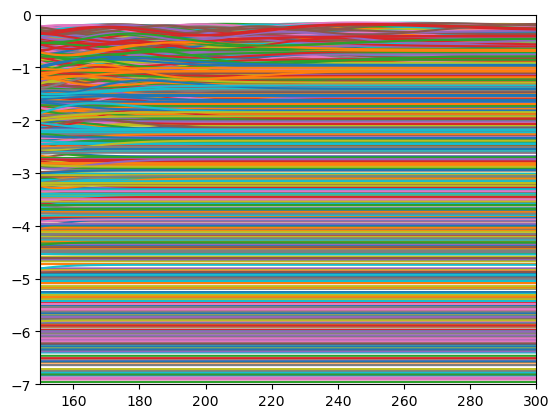

In [20]:
for i in range(len(TrueVals)):
    for j in range(len(TruePhis[i])):
        plt.plot(r_grid, TruePhis[i][j] + TrueVals[i][j])
        #plt.plot(r_grid, Phi_b2[i][j])

plt.ylim(-7,0)
plt.xlim(150,300)

In [21]:
num_of_states = 0
for i in range(len(TrueVals)):
    a_len = len(TrueVals[i])
    num_of_states += a_len

print(num_of_states)

dos = num_of_states/7
ms = 1/dos

print(f'density of states N = {dos} states/GHz')
print(f'mean spacing d = {ms} GHz')


914
density of states N = 130.57142857142858 states/GHz
mean spacing d = 0.007658643326039386 GHz


(0.0, 300.0)

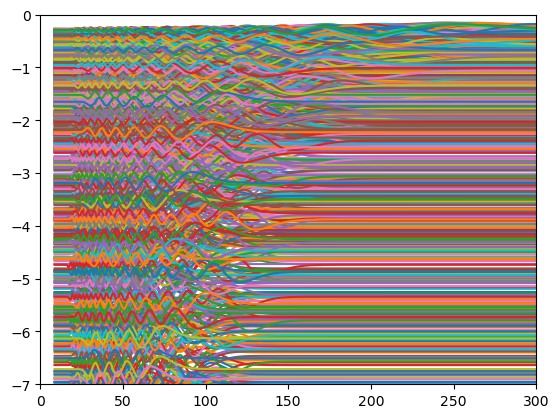

In [22]:
for i in range(len(W)):
    for j in range(len(Phi_b2[i])):
        plt.plot(r_grid, Phi_b2[i][j] + H_to_GHz*True_vals[i][j])
        #plt.plot(r_grid, Phi_b2[i][j])

plt.ylim(-7,0)
plt.xlim(0,300)

# Look at GS wavefunctions, find scattering lengths such that node at low freqeuncy shifts

In [29]:
print((r1_i, r2_i))

(50, 4700)


In [30]:
def Sigma_PA_hw_pot(omega_range, Vrr, Ground_State, Ground_grid, Bound_States, Bound_Energies, Collision_E, Intensity): # calculate cross section over a range of laser frequencies
     
    VLJ_PA = Vrr
    Psi_Scattering = scipy.interpolate.CubicSpline(Ground_grid, Ground_State)
    wave_num_sq = 2*mu*Eo
    Gamma_vals = []
    FC_vals = []
    K_N = []
    E_0 = np.sqrt(Intensity)*Ecgs_to_Eamu
    U_squared = E_0**2
    for i in range(len(Bound_States)):
        for j in range(len(Bound_States[i])):
            FC_n = np.abs(np.trapz(np.conjugate(Bound_States[i][j])*Psi_Scattering(r_grid), r_grid))**2
            FC_vals.append([FC_n, i, j])
            Gamma_n = 2*np.pi*U_squared*FC_n
            Gamma_vals.append(Gamma_n)
            Kn_num = -1*(Gamma_n*0.5)
            Detuning = (H_to_GHz*Bound_Energies[i][j] - omega_range)
            Kn_den = (H_to_GHz*Collision_E - Detuning) + I*gamma*0.5
            Kn = np.array((Kn_num/Kn_den))
            K_N.append(Kn)
   
    K = sum(K_N)
    S_num = 1 + I*K
    S_den = 1 + -1*I*K
    S = S_num/S_den
    S_prob = 1 - np.abs(S)**2
    Sigma_PA_frequency = (S_prob)
    return(Sigma_PA_frequency, Gamma_vals, FC_vals)

In [31]:
#Omega_test_range = np.linspace(-7, -0.45, len(r_grid))
#Sigma_test = Sigma_PA_hw_pot(Omega_test_range, VLJ_1, Psi_1, R_grid, Phi_b2, True_vals, Eo, 50)[0]

#plt.plot(Omega_test_range, np.log(Sigma_test))

# Varied C6 below

In [33]:
def wavefunction_LJ(Energy, M, rmin, rmax, h, C6, C12): # Numerov method function to find psi(r)
    r_range = np.linspace(rmin, rmax, M - 1)
    psi = np.zeros(M-1)
    a_VLJ = (C12*(1/r_range**12)) - (C6*(1/r_range**6))
    psi[0] = 0 # impose boundary condition psi(0) = 0
    psi[1] = h # let psi(1) = the spacing length
    #print(f' psi[1] = {psi[1]}')
    ksq = 2*mu*(Energy - a_VLJ) # wave number squared for the energy
    k_p = np.sqrt(2*mu*Eo)

    for i in range(2,M - 1):  # Numerov Algorithm, range is 2 -> N since psi(0), psi(1) already set
        #if i < 100:
           # print(f' first term in numerator is {(2*(1 - (5/12)*(dr**2)*ksq[i-1])*psi[i-1])}')
           # print(f' the numerator is {((2*(1 - (5/12)*(dr**2)*ksq[i-1])*psi[i-1]) - ((1 + (1/12)*(dr**2)*ksq[i-2])*psi[i-2]))}')
        psi[i] = ((2*(1 - (5/12)*(h**2)*ksq[i-1])*psi[i-1]) - ((1 + (1/12)*(h**2)*ksq[i-2])*psi[i-2]))/(1 + (1/12)*(h**2)*ksq[i])
    Psi_f = psi/max(psi) # divide Psi by its largest value to qvoid it becoming too large
    Psi_prime = np.gradient(Psi_f, r_range) # find the derivate over the grid r
    
    # Energy Normalization
    A_term = Psi_f[-1]**2
    B_term = Psi_prime[-1]**2
    B_coef = 1/(ksq[-1])
    U_sq = A_term + B_coef*B_term
    U = np.sqrt(U_sq)
    #print(k_p)
    norm_factor = np.sqrt(((2*mu)/(np.pi*k_p)))
    #print((U,norm_factor))
    
    Psi_Energy_Normalized = (1/U)*(Psi_f)*norm_factor
    
        
    return Psi_Energy_Normalized

def Psilinear(wavefct, r_range):
    
    
    m = (wavefct[-1] - wavefct[-2])*(1/(r_range[-1] - r_range[-2]))
    b = wavefct[-1] - (m*r_range[-1])
    y = m*r_range + b
    ro = -b/m
    return [y,ro]


In [34]:

C12I = 3.6e10 # C12 coefficient in Eh*a0^12
C6I = 3.3e-2*2e5 # C6 coefficient in Eh*a0^6

#linepsi = Psilinear(rr)
#plt.plot(rr, linepsi[0], label = 'f(r) trace', color = 'lightsalmon')
#Eo = 3.166808534191e-12 #initial energy in Hartrees, Eo = 1uK
#r1 = 4 # starting iteration distance in ao
#r2 = 704 # ending iteration distance ao
#numpts = int(((r2 - r1)*(1/dr1)) + 1) # number of points between r1, r2 given step size dr
#rr = np.linspace(r1,r2, numpts) # radial distance grid

In [35]:
def scattering_lengths(C12_array, C6val, spacing_grid):
    as_C12 = []
    for i in range(len(C12_array)):
        Current_C12 = C12_array[i]
        Current_spacing = spacing_grid

        numpts_a = int(((r2 - r1)*(1/Current_spacing)) + 1) # number of points between r1, r2 given step size dr
        rr_a = np.linspace(r1, r2, numpts_a) # radial distance grid
        
        psi = np.zeros(numpts_a)
        Psi = wavefunction_LJ(0, numpts_a, r1, r2, Current_spacing, C6val, Current_C12)
        linepsi = Psilinear(Psi, rr_a)
        as_C12.append(linepsi[1])
       # if i == int(0.5*len(C12_array)):
       #     print('half way there!')
       # if i == int(0.9*len(C12_array)):
       #     print('almost there!')

    return as_C12

In [36]:
print(C6_list)

[  6600.  54950. 103300. 151650. 200000.]


# C6 = $6600E_ha_0^6$

In [38]:
C12_test1 = 3.6e10

An_LJpot1 = (C12_test1/(R_grid**12)) - (C6_list[0]/(R_grid**6))
a_minn1 = min(An_LJpot1)

print(a_minn1*H_to_K)

k_max1 = np.sqrt(2*mu*(Eo - a_minn1))
lamb_min1 = (2*np.pi)*(1/k_max1)
dr_t1 = lamb_min1*0.1
print(dr_t1)

r6_1 = (C6_list[0]*mu*2)**(0.25)
print(f'r6_2 = {r6_1}a_0')

-95.52114453296394
0.1073828648480578
r6_2 = 165.32102632974883a_0


In [39]:
print((2*mu)/(np.pi*np.sqrt(2*mu*Eo)))

60176017.411419824


1033.927997378546


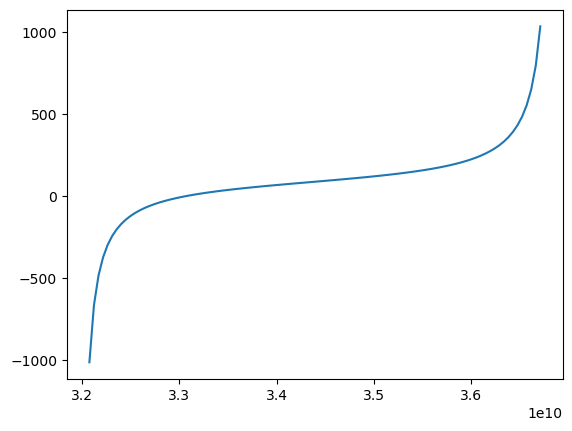

In [40]:
a_C12_array_1 = np.linspace(3.20737e10, 3.671e10, 100)

sum_as1 = scattering_lengths(a_C12_array_1, C6_list[0], dr1)
print(sum_as1[-1])


plt.plot(a_C12_array_1, sum_as1)

In [41]:
maxlj1 = (a_C12_array_1[0]/(R_grid**12)) - (C6_list[0]/(R_grid**6))
min_min1 = min(maxlj1)
k_max1 = np.sqrt(2*mu*(Eo - min_min1))
lamb_min1 = (2*np.pi)*(1/k_max1)
dr_test1 = lamb_min1*0.05

print(dr_test1)

0.05067910150409965


In [42]:
psi_D1 = []
GS_D1 = []
R_grids_D1 = []
depths1 = []

for i in range(len(a_C12_array_1)):

    N_D1 = int((R2-R1)/dr_test1)
    #print(N_D2)
    ipap_D1 = np.arange(1,N_D1, 1.0)
    R_grid_D1 = R1 + dr_test1*ipap_D1
    R_grids_D1.append(R_grid_D1)
    VLJ_D1 = (a_C12_array_1[i]/(R_grid_D1**12)) - (C6_list[0]/(R_grid_D1**6))
    min_d1 = min(VLJ_D1)
    depths1.append(H_to_K*min_d1)
    GS_D1.append(VLJ_D1)
    Psi_D1 = Numerov(Eo, N_D1-1, VLJ_D1, dr_test1, R_grid_D1) # wave function Psi
    D1_interp = scipy.interpolate.CubicSpline(R_grid_D1, Psi_D1)
    psi_D1.append(D1_interp(R_grid_D1))
    if i == 1:
        print('it at least loops')
    if i == int(0.3*len(a_C12_array_1)):
        print('a third')
    if i == int(len(a_C12_array_1)/2):
        print('halfway there')
    if i == int(0.9*len(a_C12_array_1)):
        print('almost there')

it at least loops
a third
halfway there
almost there


In [43]:
Omega_1 = np.linspace(-7,-0.47,len(r_grid))
Crosses1 = []
for i in range(len(psi_D1)):
    #Omega_1 = np.linspace(-7,0,len(sub_grids[i]))
    Sigma_D = Sigma_PA_hw_pot(Omega_1, GS_D1[i], psi_D1[i], R_grids_D1[i], Phi_b2, True_vals, Eo, 10)
    Crosses1.append(Sigma_D[0])

(-7.0, -0.47)

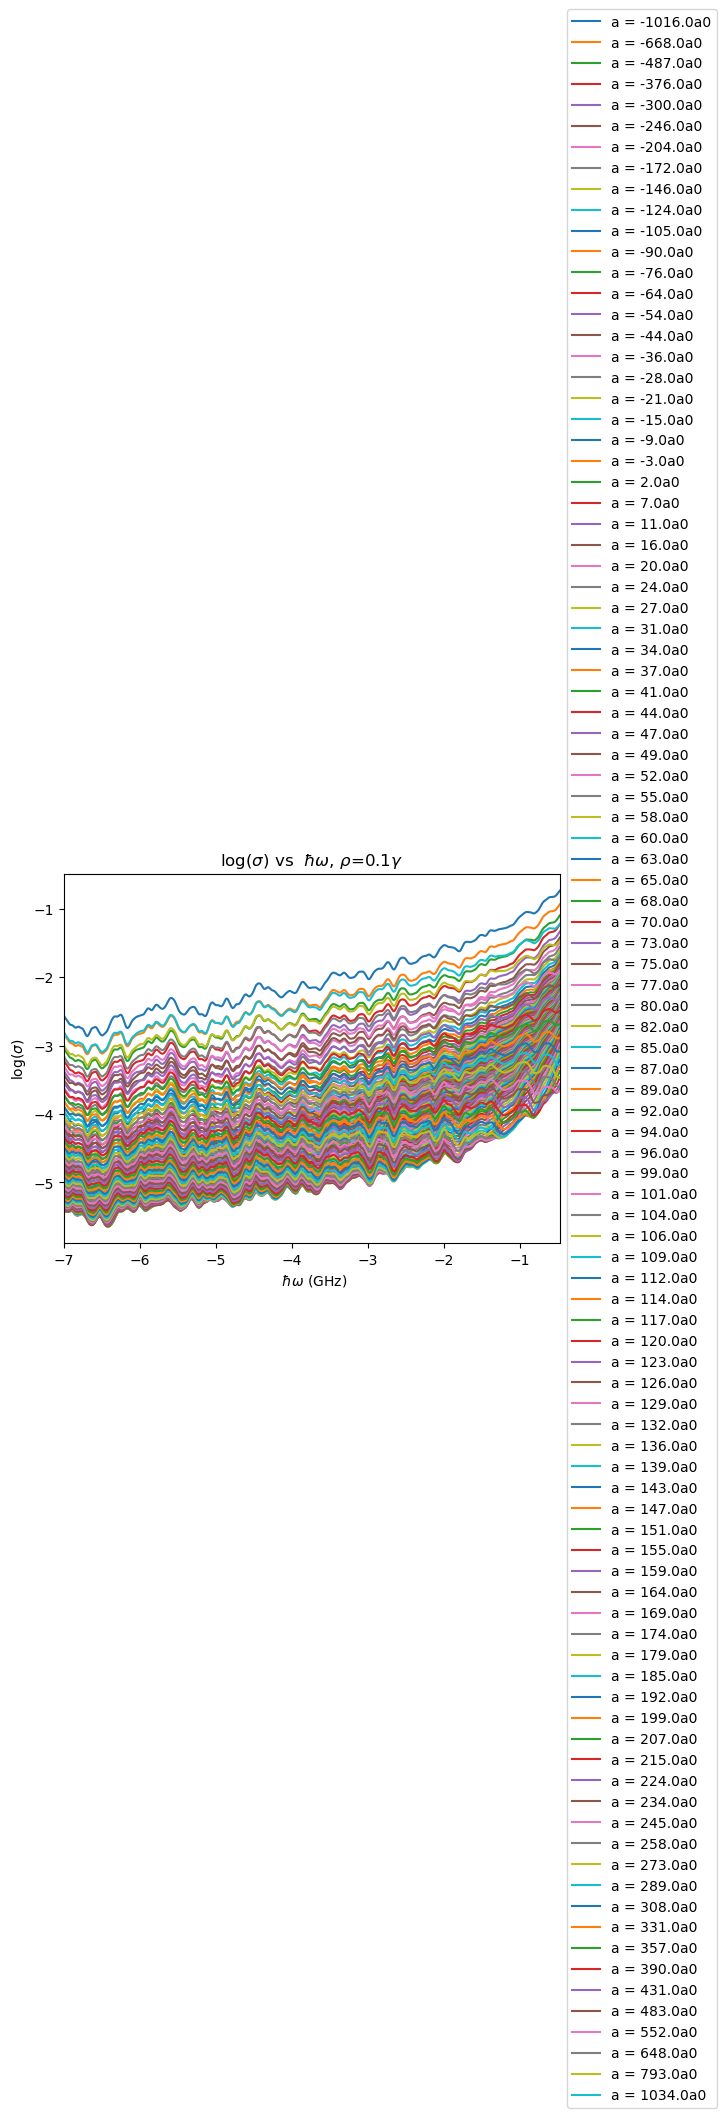

In [44]:

for i in range(len(psi_D1)):
    plt.plot(Omega_1, np.log10(Crosses1[i]), label = f'a = {round(sum_as1[i],0)}a0')

plt.xlabel(' $ \\hbar \\omega $ (GHz)')
plt.ylabel('log($\\sigma$)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('log($\\sigma$) vs  $\\hbar \\omega $, $\\rho$=0.1$\\gamma$')

#plt.xlim(-2,-1.8)
#plt.ylim(-7700/1000,-7400/1000)

plt.xlim(-7,-0.47)

In [45]:
dw = Omega_1[1] - Omega_1[0]
print(dw)

0.0014049053356286478


In [46]:
Lg_Sigma1 = []
for i in range(len(Crosses1)):
    Lg_Sigma1.append(np.log10(Crosses1[i]))

# Mean cross section,  C6 = $6600E_ha_0^6$

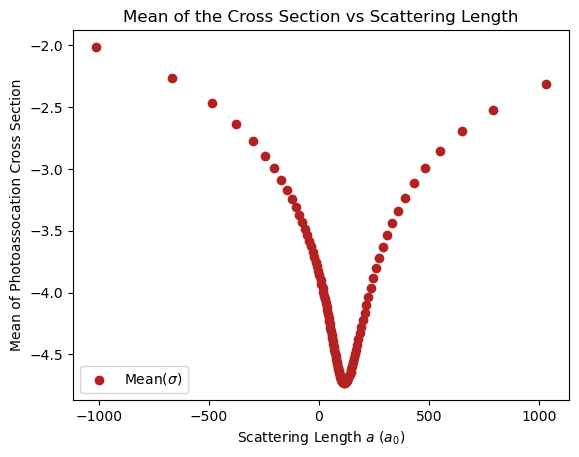

In [81]:
a_sl1 = []
a_mean1 = []

for i in range(len(Lg_Sigma1)):
    a_sl1.append(round(sum_as1[i],0))
    a_mean1.append(np.mean(Lg_Sigma1[i]))

#plt.vlines(a_sl1[62],-11,0, color = 'black')

plt.scatter(a_sl1, a_mean1, color = 'firebrick', label = 'Mean($\\sigma$)')
plt.ylabel('Mean log($\\sigma$)')
plt.xlabel('Scattering Length $a$ ($a_0$)')
plt.title('Mean of The Cross Section vs Scattering Length')

#plt.xlim(-1000,1000)

plt.ylabel('Mean of Photoassocation Cross Section')
plt.xlabel('Scattering Length $a$ ($a_0$)')
plt.title('Mean of the Cross Section vs Scattering Length')
plt.legend(loc='lower left')

plt.savefig('mean_sig.png', bbox_inches='tight')

In [75]:
for i in range(len(a_mean1)):
    if a_mean1[i] == min(a_mean1):
        print(a_sl1[i])

114.0


# C6 = $54950E_ha_0^6$

In [87]:
C12_test2 = 2.3e12

An_LJpot2 = (C12_test2/(R_grid**12)) - (C6_list[1]/(R_grid**6))
a_minn2 = min(An_LJpot2)

print(a_minn2*H_to_K)

k_max2 = np.sqrt(2*mu*(Eo - a_minn2))
lamb_min2 = (2*np.pi)*(1/k_max2)
dr_t2 = lamb_min2*0.1
print(dr_t2)

r6_2 = (C6_list[1]*mu*2)**(0.25)
print(f'r6_2 = {r6_2}a_0')

-103.63758895583166
0.10309226815267569
r6_2 = 280.8238784408854a_0


1190.8248487197911


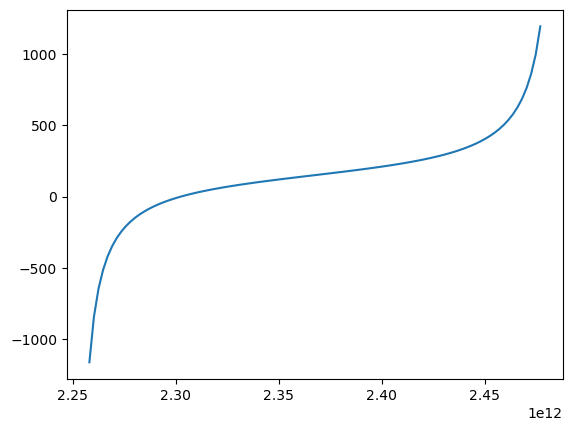

In [89]:
a_C12_array_2 = np.linspace(2.258e12, 2.477e12, 100)

sum_as2 = scattering_lengths(a_C12_array_2, C6_list[1], dr1)
print(sum_as2[-1])


plt.plot(a_C12_array_2, sum_as2)

In [91]:
maxlj2 = (a_C12_array_2[0]/(R_grid**12)) - (C6_list[1]/(R_grid**6))
min_min2 = min(maxlj2)
k_max2 = np.sqrt(2*mu*(Eo - min_min2))
lamb_min2 = (2*np.pi)*(1/k_max2)
dr_test2 = lamb_min2*0.05

print(dr_test2)

0.05107778436930528


In [93]:
psi_D2 = []
GS_D2 = []
R_grids_D2 = []
depths2 = []

for i in range(len(a_C12_array_2)):

    N_D2 = int((R2-R1)/dr_test2)
    #print(N_D2)
    ipap_D2 = np.arange(1,N_D2, 1.0)
    R_grid_D2 = R1 + dr_test2*ipap_D2
    R_grids_D2.append(R_grid_D2)
    VLJ_D2 = (a_C12_array_2[i]/(R_grid_D2**12)) - (C6_list[1]/(R_grid_D2**6))
    min_d2 = min(VLJ_D2)
    depths2.append(H_to_K*min_d2)
    GS_D2.append(VLJ_D2)
    Psi_D2 = Numerov(Eo, N_D2-1, VLJ_D2, dr_test2, R_grid_D2) # wave function Psi
    D2_interp = scipy.interpolate.CubicSpline(R_grid_D2, Psi_D2)
    psi_D2.append(D2_interp(R_grid_D2))
    if i == 1:
        print('it at least loops')
    if i == int(0.3*len(a_C12_array_2)):
        print('a third')
    if i == int(len(a_C12_array_2)/2):
        print('halfway there')
    if i == int(0.9*len(a_C12_array_2)):
        print('almost there')

it at least loops
a third
halfway there
almost there


In [94]:
Omega_2 = np.linspace(-7,-0.47,len(r_grid))
Crosses2 = []
for i in range(len(psi_D2)):
    #Omega_1 = np.linspace(-7,0,len(sub_grids[i]))
    Sigma_D2 = Sigma_PA_hw_pot(Omega_2, GS_D2[i], psi_D2[i], R_grids_D2[i], Phi_b2, True_vals, Eo, 10)
    Crosses2.append(Sigma_D2[0])

(-7.0, -0.47)

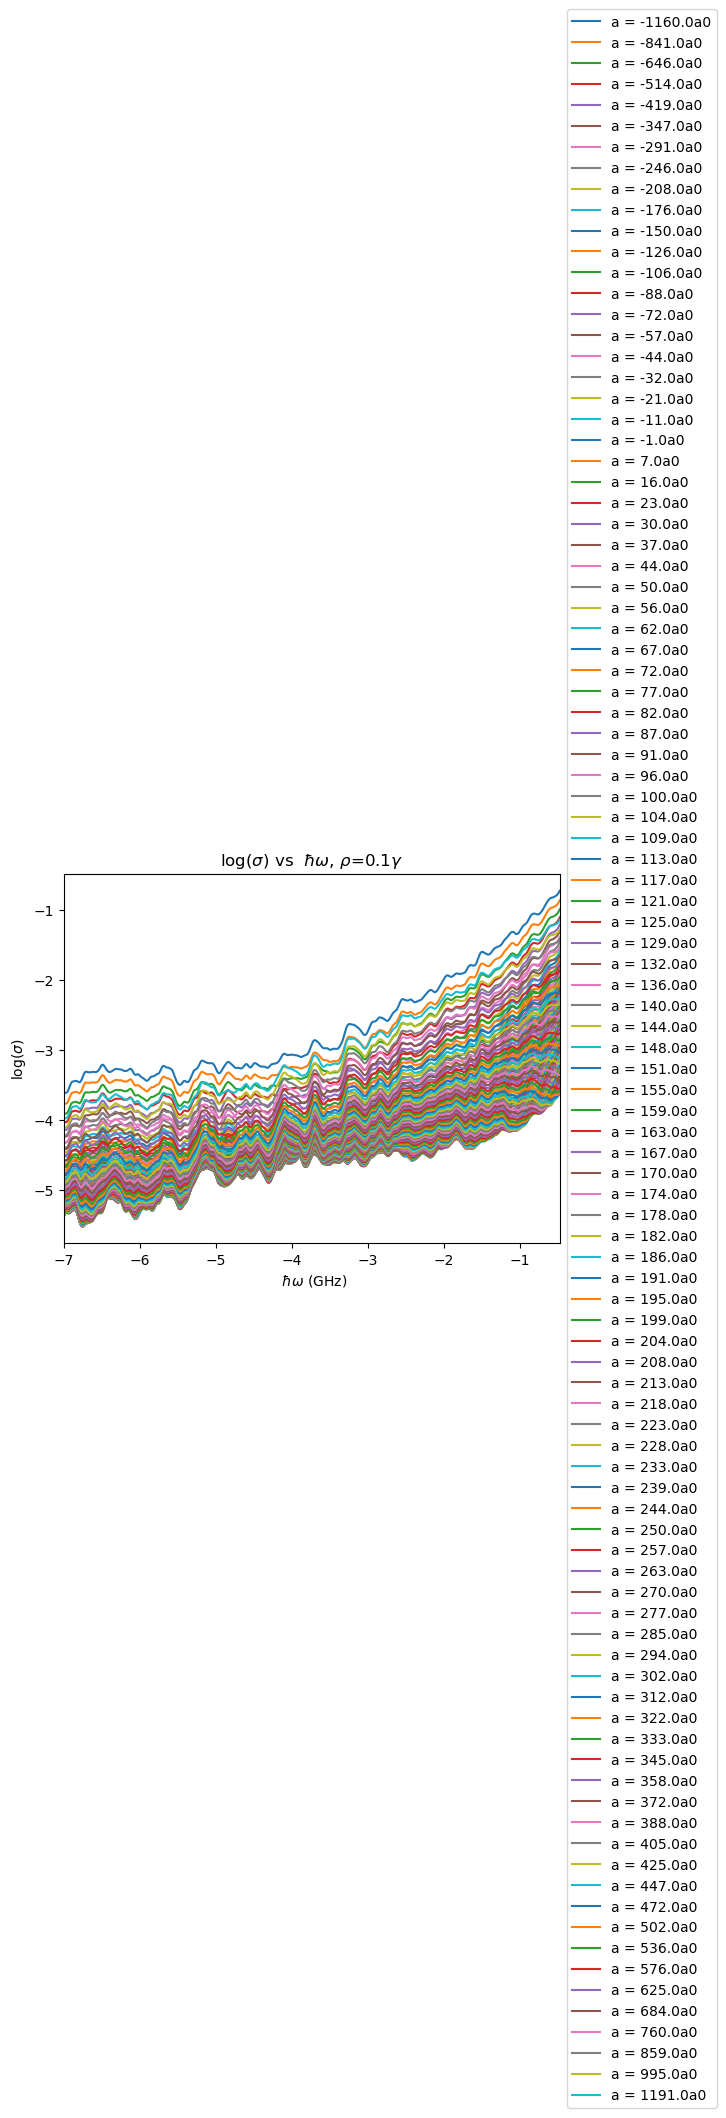

In [95]:

for i in range(len(psi_D2)):
    plt.plot(Omega_2, np.log10(Crosses2[i]), label = f'a = {round(sum_as2[i],0)}a0')

plt.xlabel(' $ \\hbar \\omega $ (GHz)')
plt.ylabel('log($\\sigma$)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('log($\\sigma$) vs  $\\hbar \\omega $, $\\rho$=0.1$\\gamma$')

#plt.xlim(-2,-1.8)
#plt.ylim(-7700/1000,-7400/1000)

plt.xlim(-7,-0.47)

In [96]:
Lg_Sigma2 = []
for i in range(len(Crosses2)):
    Lg_Sigma2.append(np.log10(Crosses2[i]))

# Mean cross section,  C6 = $54950E_ha_0^6$

(-1000.0, 1000.0)

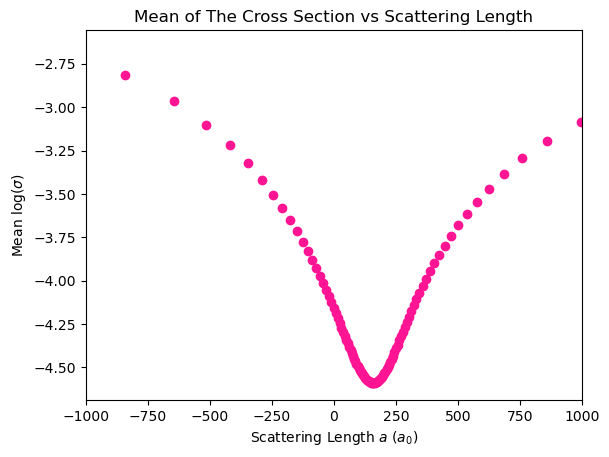

In [119]:
a_sl2 = []
a_mean2 = []

for i in range(len(Lg_Sigma2)):
    a_sl2.append(round(sum_as2[i],0))
    a_mean2.append(np.mean(Lg_Sigma2[i]))

#plt.vlines(a_sl1[62],-11,0, color = 'black')

plt.scatter(a_sl2, a_mean2, color = 'deeppink')
plt.ylabel('Mean log($\\sigma$)')
plt.xlabel('Scattering Length $a$ ($a_0$)')
plt.title('Mean of The Cross Section vs Scattering Length')

plt.xlim(-1000,1000)

In [121]:
for i in range(len(a_mean2)):
    if a_mean2[i] == min(a_mean2):
        print(a_sl2[i])

159.0


# C6 = $103300E_ha_0^6$

In [124]:
C12_test3 = 8.8e12

An_LJpot3 = (C12_test3/(R_grid**12)) - (C6_list[2]/(R_grid**6))
a_minn3 = min(An_LJpot3)

print(a_minn3*H_to_K)

k_max3 = np.sqrt(2*mu*(Eo - a_minn3))
lamb_min3 = (2*np.pi)*(1/k_max3)
dr_t3 = lamb_min3*0.1
print(dr_t3)

r6_3 = (C6_list[2]*mu*2)**(0.25)
print(f'r6_3 = {r6_3}a_0')

-95.71451783589924
0.10727433649700345
r6_3 = 328.82678722890313a_0


1126.9958690760607


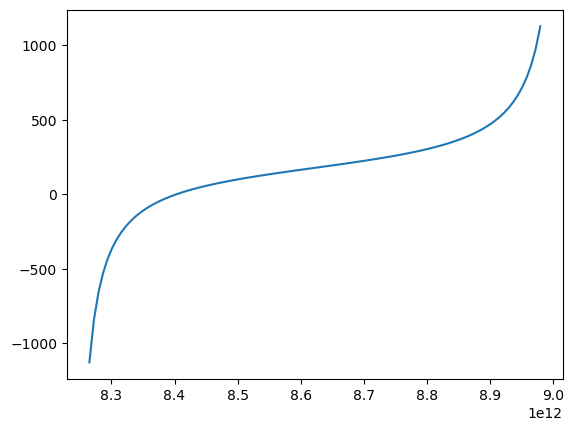

In [130]:
a_C12_array_3 = np.linspace(8.265e12, 8.98e12, 100)

sum_as3 = scattering_lengths(a_C12_array_3, C6_list[2], dr1)
print(sum_as3[-1])


plt.plot(a_C12_array_3, sum_as3)

In [131]:
maxlj3 = (a_C12_array_3[0]/(R_grid**12)) - (C6_list[2]/(R_grid**6))
min_min3 = min(maxlj3)
k_max3 = np.sqrt(2*mu*(Eo - min_min3))
lamb_min3 = (2*np.pi)*(1/k_max3)
dr_test3 = lamb_min3*0.05

print(dr_test3)

0.051977664013090764


In [147]:
psi_D3 = []
GS_D3 = []
R_grids_D3 = []
depths3 = []

for i in range(len(a_C12_array_3)):

    N_D3 = int((R2-R1)/dr_test3)
    #print(N_D2)
    ipap_D3 = np.arange(1,N_D3, 1.0)
    R_grid_D3 = R1 + dr_test3*ipap_D3
    R_grids_D3.append(R_grid_D3)
    VLJ_D3 = (a_C12_array_3[i]/(R_grid_D3**12)) - (C6_list[2]/(R_grid_D3**6))
    min_d3 = min(VLJ_D3)
    depths3.append(H_to_K*min_d3)
    GS_D3.append(VLJ_D3)
    Psi_D3 = Numerov(Eo, N_D3-1, VLJ_D3, dr_test3, R_grid_D3) # wave function Psi
    D3_interp = scipy.interpolate.CubicSpline(R_grid_D3, Psi_D3)
    psi_D3.append(D3_interp(R_grid_D3))
    if i == 1:
        print('it at least loops')
    if i == int(0.3*len(a_C12_array_3)):
        print('a third')
    if i == int(len(a_C12_array_3)/2):
        print('halfway there')
    if i == int(0.9*len(a_C12_array_3)):
        print('almost there')

it at least loops
a third
halfway there
almost there


In [148]:
Omega_3 = np.linspace(-7,-0.47,len(r_grid))
Crosses3 = []
for i in range(len(psi_D3)):
    #Omega_1 = np.linspace(-7,0,len(sub_grids[i]))
    Sigma_D3 = Sigma_PA_hw_pot(Omega_3, GS_D3[i], psi_D3[i], R_grids_D3[i], Phi_b2, True_vals, Eo, 10)
    Crosses3.append(Sigma_D3[0])

(-7.0, -0.47)

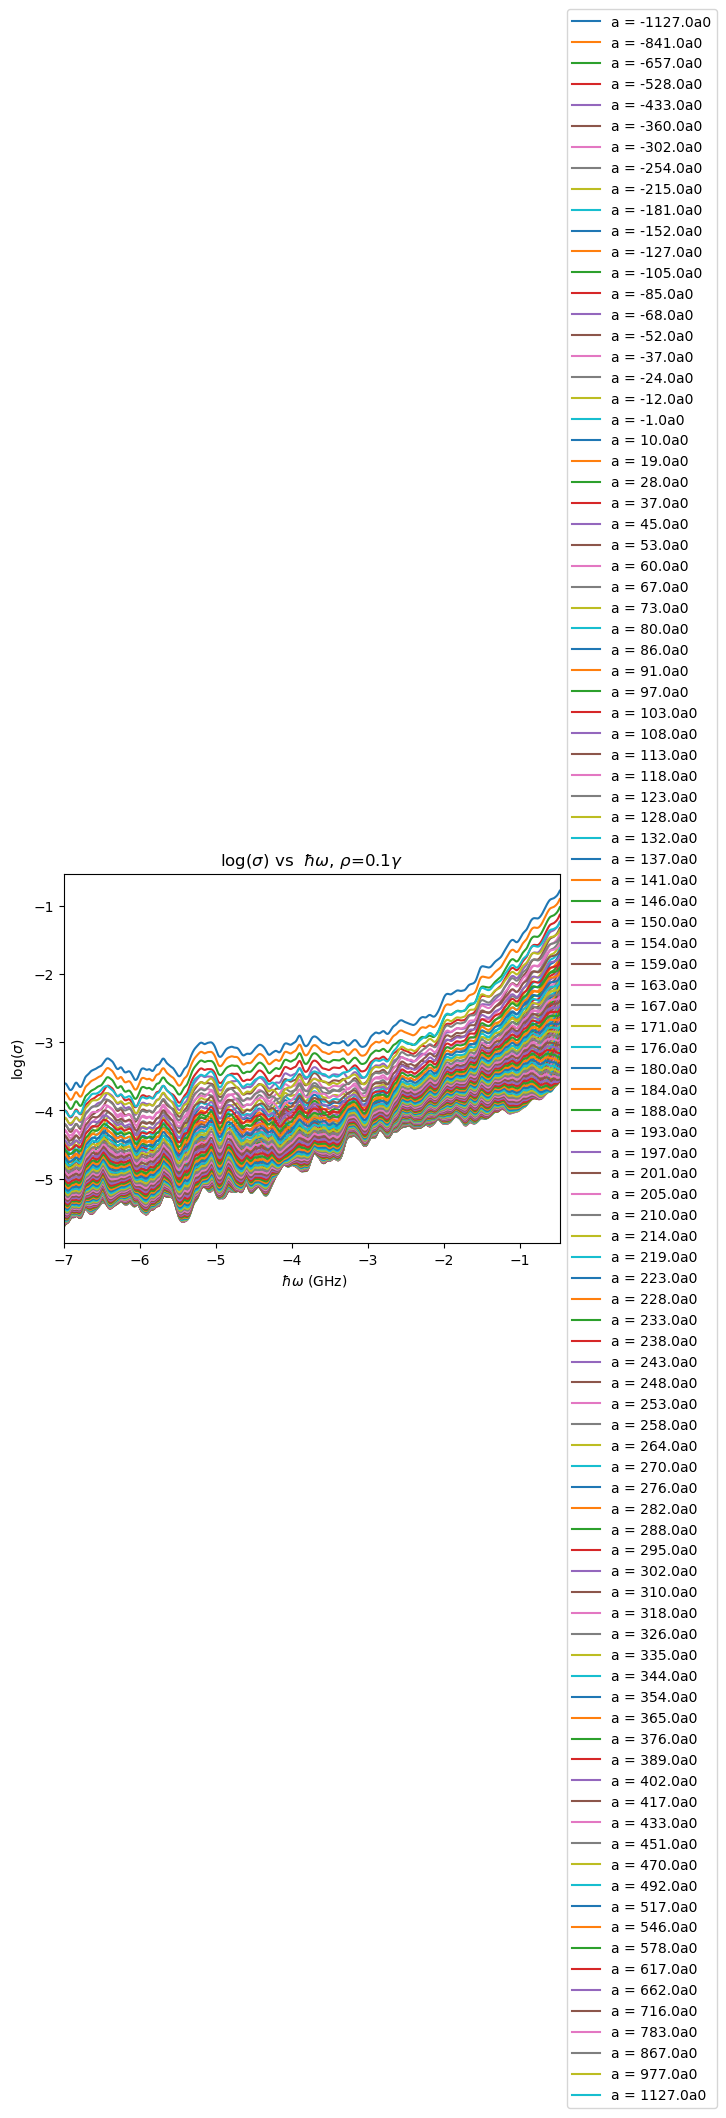

In [149]:

for i in range(len(psi_D3)):
    plt.plot(Omega_3, np.log10(Crosses3[i]), label = f'a = {round(sum_as3[i],0)}a0')

plt.xlabel(' $ \\hbar \\omega $ (GHz)')
plt.ylabel('log($\\sigma$)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('log($\\sigma$) vs  $\\hbar \\omega $, $\\rho$=0.1$\\gamma$')

#plt.xlim(-2,-1.8)
#plt.ylim(-7700/1000,-7400/1000)

plt.xlim(-7,-0.47)

In [150]:
Lg_Sigma3 = []
for i in range(len(Crosses3)):
    Lg_Sigma3.append(np.log10(Crosses3[i]))

# Mean cross section,  C6 = $103300E_ha_0^6$

(-1000.0, 1000.0)

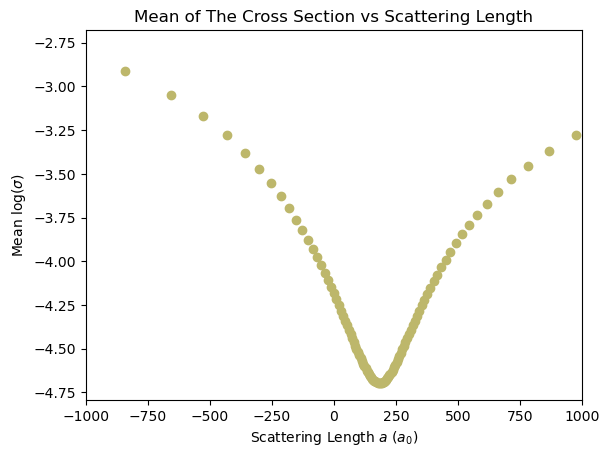

In [152]:
a_sl3 = []
a_mean3 = []

for i in range(len(Lg_Sigma3)):
    a_sl3.append(round(sum_as3[i],0))
    a_mean3.append(np.mean(Lg_Sigma3[i]))

#plt.vlines(a_sl1[62],-11,0, color = 'black')

plt.scatter(a_sl3, a_mean3, color = 'darkkhaki')
plt.ylabel('Mean log($\\sigma$)')
plt.xlabel('Scattering Length $a$ ($a_0$)')
plt.title('Mean of The Cross Section vs Scattering Length')

plt.xlim(-1000,1000)

In [153]:
for i in range(len(a_mean3)):
    if a_mean3[i] == min(a_mean3):
        print(a_sl3[i])

184.0


# C6 = $151650E_ha_0^6$

In [155]:
C12_test4 = 1.9e13

An_LJpot4 = (C12_test4/(R_grid**12)) - (C6_list[3]/(R_grid**6))
a_minn4 = min(An_LJpot4)

print(a_minn4*H_to_K)

k_max4 = np.sqrt(2*mu*(Eo - a_minn4))
lamb_min4 = (2*np.pi)*(1/k_max4)
dr_t4 = lamb_min4*0.1
print(dr_t4)

r6_4 = (C6_list[3]*mu*2)**(0.25)
print(f'r6_3 = {r6_4}a_0')

-95.55371272530842
0.1073645632891217
r6_3 = 361.9534433556503a_0


1129.4099529381704


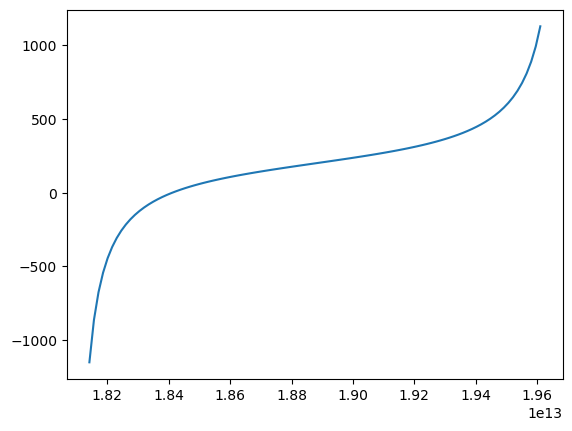

In [156]:
a_C12_array_4 = np.linspace(1.8142e13, 1.961e13, 100)

sum_as4 = scattering_lengths(a_C12_array_4, C6_list[3], dr1)
print(sum_as4[-1])


plt.plot(a_C12_array_4, sum_as4)

In [157]:
maxlj4 = (a_C12_array_4[0]/(R_grid**12)) - (C6_list[3]/(R_grid**6))
min_min4 = min(maxlj4)
k_max4 = np.sqrt(2*mu*(Eo - min_min4))
lamb_min4 = (2*np.pi)*(1/k_max4)
dr_test4 = lamb_min4*0.05

print(dr_test4)

0.05245647027440085


In [158]:
psi_D4 = []
GS_D4 = []
R_grids_D4 = []
depths4 = []

for i in range(len(a_C12_array_4)):

    N_D4 = int((R2-R1)/dr_test4)
    #print(N_D2)
    ipap_D4 = np.arange(1,N_D4, 1.0)
    R_grid_D4 = R1 + dr_test4*ipap_D4
    R_grids_D4.append(R_grid_D4)
    VLJ_D4 = (a_C12_array_4[i]/(R_grid_D4**12)) - (C6_list[3]/(R_grid_D4**6))
    min_d4 = min(VLJ_D4)
    depths4.append(H_to_K*min_d4)
    GS_D4.append(VLJ_D4)
    Psi_D4 = Numerov(Eo, N_D4-1, VLJ_D4, dr_test4, R_grid_D4) # wave function Psi
    D4_interp = scipy.interpolate.CubicSpline(R_grid_D4, Psi_D4)
    psi_D4.append(D4_interp(R_grid_D4))
    if i == 1:
        print('it at least loops')
    if i == int(0.3*len(a_C12_array_4)):
        print('a third')
    if i == int(len(a_C12_array_4)/2):
        print('halfway there')
    if i == int(0.9*len(a_C12_array_4)):
        print('almost there')

it at least loops
a third
halfway there
almost there


In [159]:
Omega_4 = np.linspace(-7,-0.47,len(r_grid))
Crosses4 = []
for i in range(len(psi_D4)):
    #Omega_1 = np.linspace(-7,0,len(sub_grids[i]))
    Sigma_D4 = Sigma_PA_hw_pot(Omega_4, GS_D4[i], psi_D4[i], R_grids_D4[i], Phi_b2, True_vals, Eo, 10)
    Crosses4.append(Sigma_D4[0])

(-7.0, -0.47)

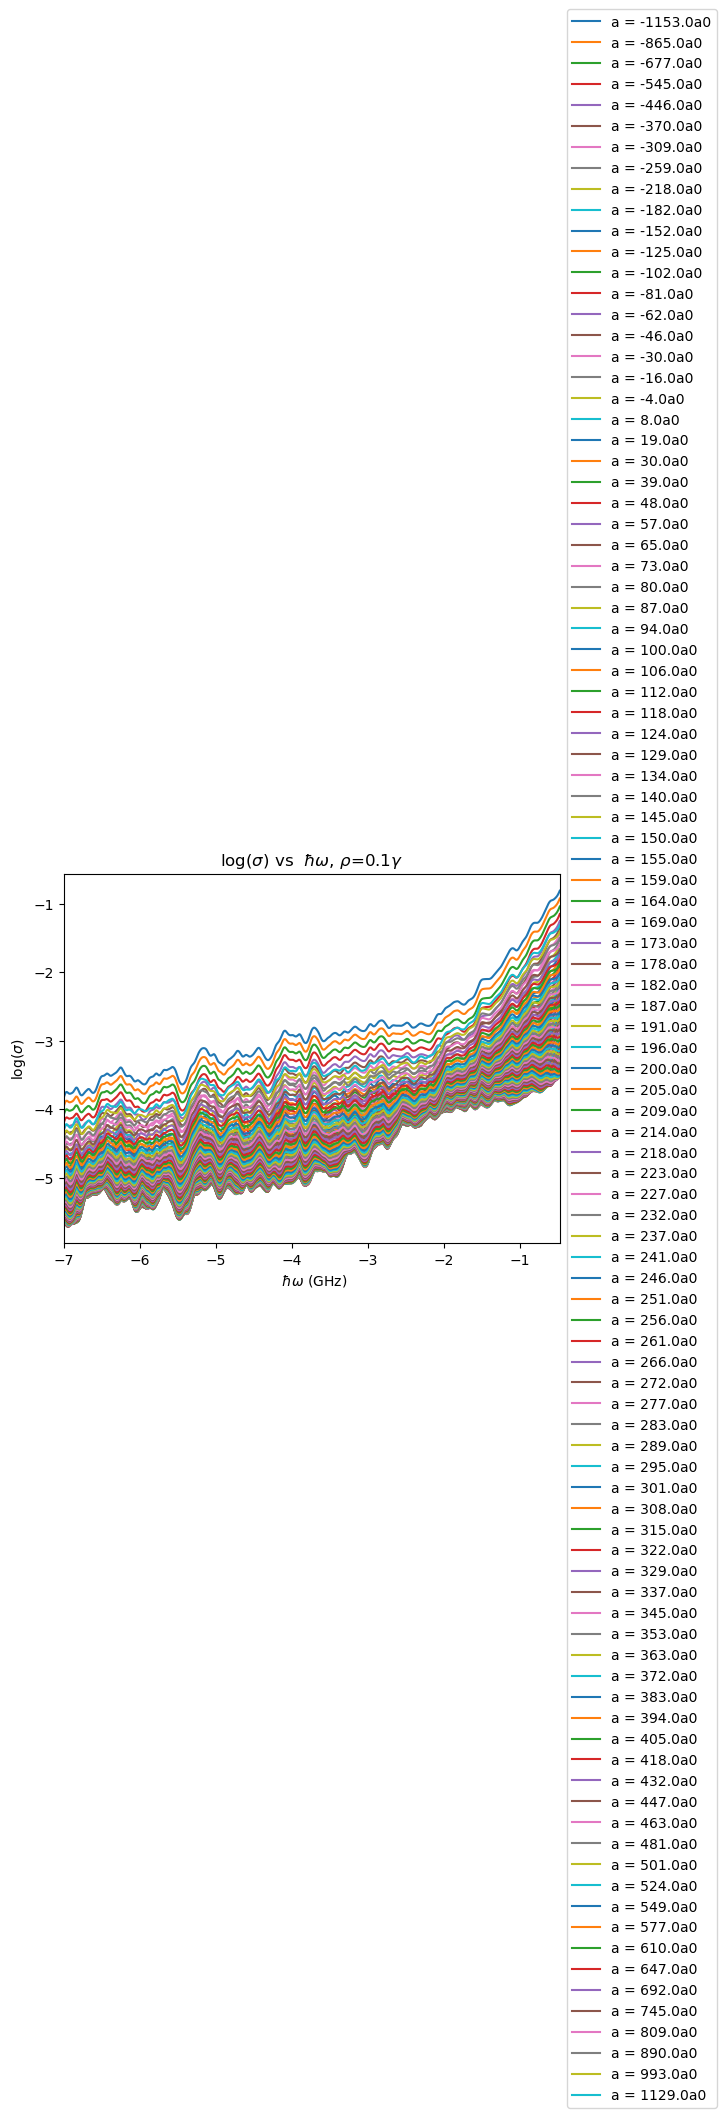

In [160]:

for i in range(len(psi_D4)):
    plt.plot(Omega_4, np.log10(Crosses4[i]), label = f'a = {round(sum_as4[i],0)}a0')

plt.xlabel(' $ \\hbar \\omega $ (GHz)')
plt.ylabel('log($\\sigma$)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('log($\\sigma$) vs  $\\hbar \\omega $, $\\rho$=0.1$\\gamma$')

#plt.xlim(-2,-1.8)
#plt.ylim(-7700/1000,-7400/1000)

plt.xlim(-7,-0.47)

In [161]:
Lg_Sigma4 = []
for i in range(len(Crosses4)):
    Lg_Sigma4.append(np.log10(Crosses4[i]))

# Mean cross section,  C6 = $151650E_ha_0^6$

(-1000.0, 1000.0)

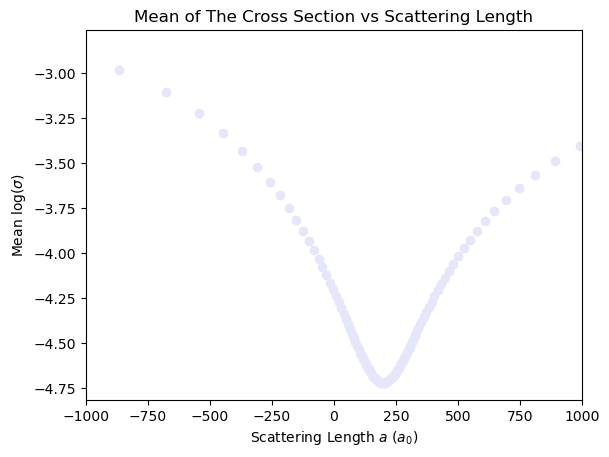

In [163]:
a_sl4 = []
a_mean4 = []

for i in range(len(Lg_Sigma4)):
    a_sl4.append(round(sum_as4[i],0))
    a_mean4.append(np.mean(Lg_Sigma4[i]))

#plt.vlines(a_sl1[62],-11,0, color = 'black')

plt.scatter(a_sl4, a_mean4, color = 'lavender')
plt.ylabel('Mean log($\\sigma$)')
plt.xlabel('Scattering Length $a$ ($a_0$)')
plt.title('Mean of The Cross Section vs Scattering Length')

plt.xlim(-1000,1000)

In [164]:
for i in range(len(a_mean4)):
    if a_mean4[i] == min(a_mean4):
        print(a_sl4[i])

200.0


Text(0.5, 1.0, 'Mean of The Cross Section vs Scattering Length')

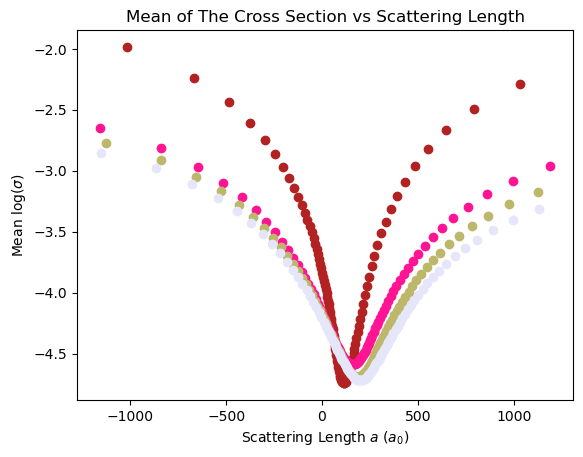

In [165]:
plt.scatter(a_sl1, a_mean1, color = 'firebrick', label = f'r6={r6_1}a_0')
plt.scatter(a_sl2, a_mean2, color = 'deeppink', label = f'r6={r6_2}a_0')
plt.scatter(a_sl3, a_mean3, color = 'darkkhaki', label = f'r6={r6_3}a_0')
plt.scatter(a_sl4, a_mean4, color = 'lavender', label = f'r6={r6_4}a_0')

plt.ylabel('Mean log($\\sigma$)')
plt.xlabel('Scattering Length $a$ ($a_0$)')
plt.title('Mean of The Cross Section vs Scattering Length')

# C6 = $200000E_ha_0^6$

In [167]:
C12_test5 = 3.0e13

An_LJpot5 = (C12_test5/(R_grid**12)) - (C6_list[4]/(R_grid**6))
a_minn5 = min(An_LJpot5)

print(a_minn5*H_to_K)

k_max5 = np.sqrt(2*mu*(Eo - a_minn5))
lamb_min5 = (2*np.pi)*(1/k_max5)
dr_t5 = lamb_min5*0.1
print(dr_t5)

r6_5 = (C6_list[4]*mu*2)**(0.25)
print(f'r6_5 = {r6_5}a_0')

-105.25446656522547
0.10229737224124574
r6_5 = 387.88198350978a_0


1150.6772581921234


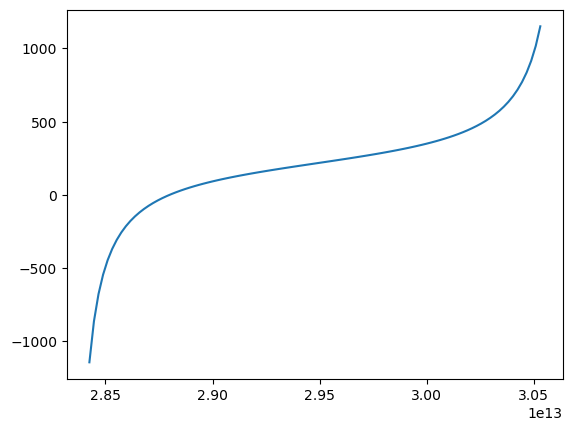

In [168]:
a_C12_array_5 = np.linspace(2.8425e13, 3.053e13, 100)

sum_as5 = scattering_lengths(a_C12_array_5, C6_list[4], dr1)
print(sum_as5[-1])


plt.plot(a_C12_array_5, sum_as5)

In [169]:
maxlj5 = (a_C12_array_5[0]/(R_grid**12)) - (C6_list[4]/(R_grid**6))
min_min5 = min(maxlj5)
k_max5 = np.sqrt(2*mu*(Eo - min_min5))
lamb_min5 = (2*np.pi)*(1/k_max5)
dr_test5 = lamb_min5*0.05

print(dr_test5)

0.04978941193012082


In [170]:
psi_D5 = []
GS_D5 = []
R_grids_D5 = []
depths5 = []

for i in range(len(a_C12_array_5)):

    N_D5 = int((R2-R1)/dr_test5)
    #print(N_D2)
    ipap_D5 = np.arange(1,N_D5, 1.0)
    R_grid_D5 = R1 + dr_test5*ipap_D5
    R_grids_D5.append(R_grid_D5)
    VLJ_D5 = (a_C12_array_5[i]/(R_grid_D5**12)) - (C6_list[4]/(R_grid_D5**6))
    min_d5 = min(VLJ_D5)
    depths5.append(H_to_K*min_d5)
    GS_D5.append(VLJ_D5)
    Psi_D5 = Numerov(Eo, N_D5-1, VLJ_D5, dr_test5, R_grid_D5) # wave function Psi
    D5_interp = scipy.interpolate.CubicSpline(R_grid_D5, Psi_D5)
    psi_D5.append(D5_interp(R_grid_D5))
    if i == 1:
        print('it at least loops')
    if i == int(0.3*len(a_C12_array_5)):
        print('a third')
    if i == int(len(a_C12_array_5)/2):
        print('halfway there')
    if i == int(0.9*len(a_C12_array_5)):
        print('almost there')

it at least loops
a third
halfway there
almost there


In [171]:
Omega_5 = np.linspace(-7,-0.47,len(r_grid))
Crosses5 = []
for i in range(len(psi_D5)):
    #Omega_1 = np.linspace(-7,0,len(sub_grids[i]))
    Sigma_D5 = Sigma_PA_hw_pot(Omega_5, GS_D5[i], psi_D5[i], R_grids_D5[i], Phi_b2, True_vals, Eo, 10)
    Crosses5.append(Sigma_D5[0])

(-7.0, -0.47)

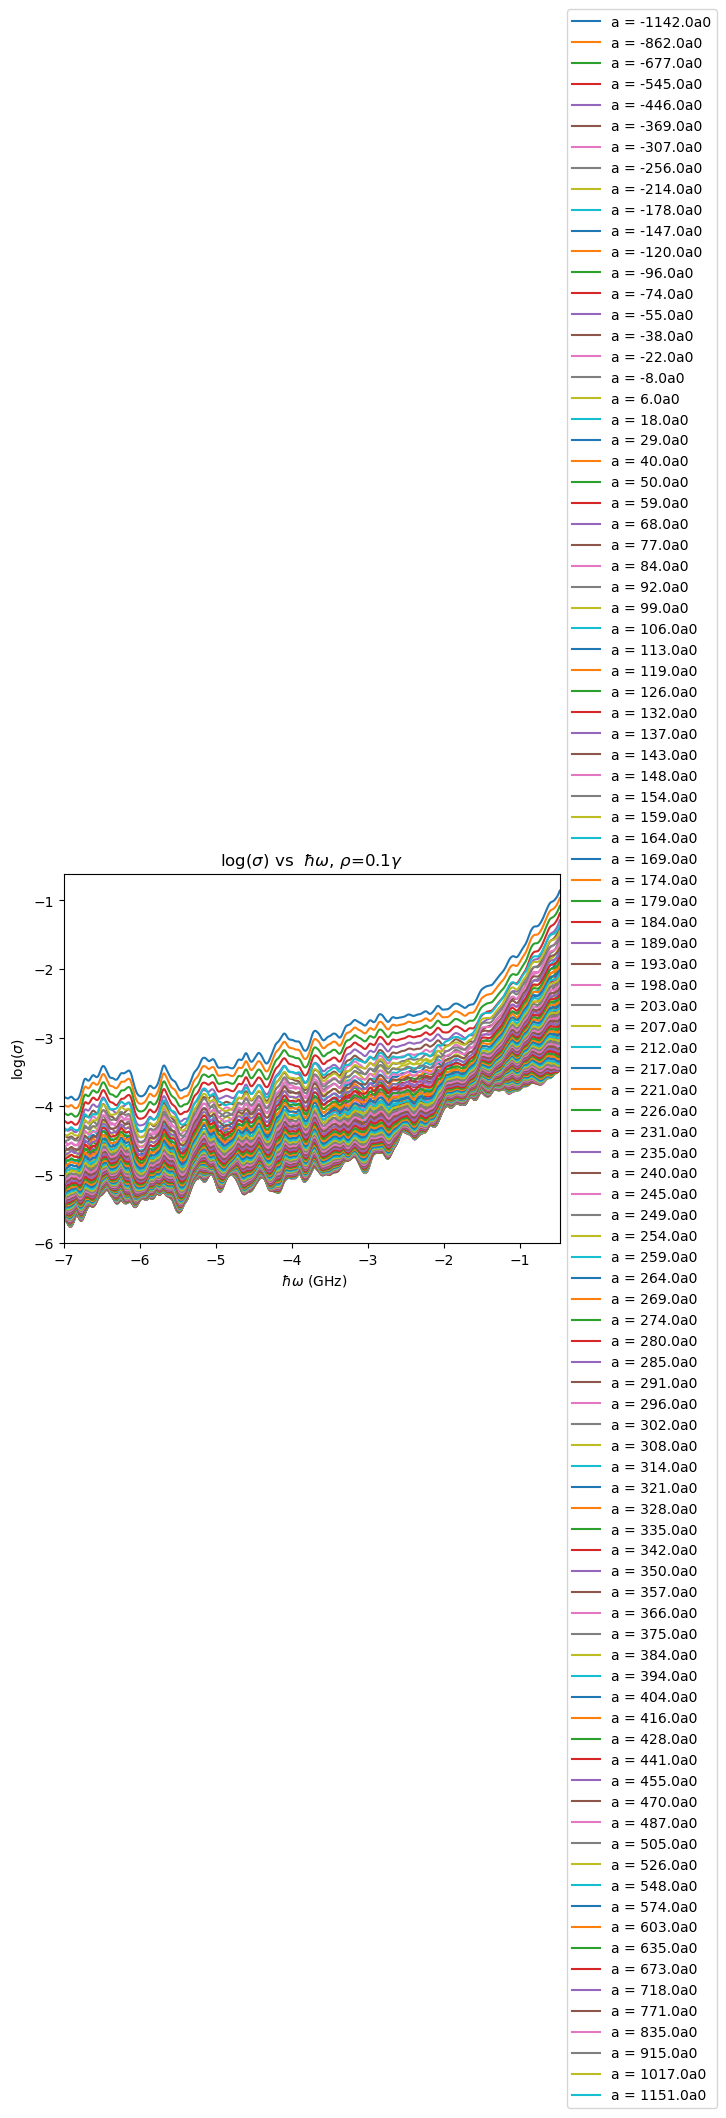

In [172]:

for i in range(len(psi_D5)):
    plt.plot(Omega_5, np.log10(Crosses5[i]), label = f'a = {round(sum_as5[i],0)}a0')

plt.xlabel(' $ \\hbar \\omega $ (GHz)')
plt.ylabel('log($\\sigma$)')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.title('log($\\sigma$) vs  $\\hbar \\omega $, $\\rho$=0.1$\\gamma$')

#plt.xlim(-2,-1.8)
#plt.ylim(-7700/1000,-7400/1000)

plt.xlim(-7,-0.47)

In [173]:
Lg_Sigma5 = []
for i in range(len(Crosses5)):
    Lg_Sigma5.append(np.log10(Crosses5[i]))

# Mean cross section,  C6 = $200000E_ha_0^6$

Text(0.5, 1.0, 'Mean of The Cross Section vs Scattering Length')

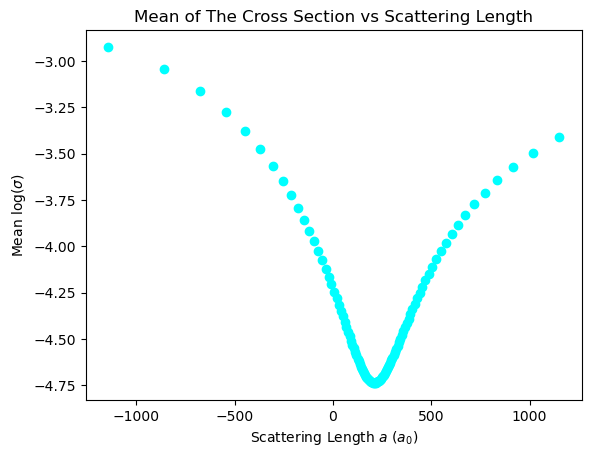

In [203]:
a_sl5 = []
a_mean5 = []

for i in range(len(Lg_Sigma5)):
    a_sl5.append(round(sum_as5[i],0))
    a_mean5.append(np.mean(Lg_Sigma5[i]))

#plt.vlines(a_sl1[62],-11,0, color = 'black')

plt.scatter(a_sl5, a_mean5, color = 'aqua')
plt.ylabel('Mean log($\\sigma$)')
plt.xlabel('Scattering Length $a$ ($a_0$)')
plt.title('Mean of The Cross Section vs Scattering Length')

#plt.xlim(-1000,1000)

In [180]:
for i in range(len(a_mean5)):
    if a_mean5[i] == min(a_mean5):
        print(a_sl5[i])

212.0


In [211]:
for i in range(len(a_mean5)):
    if a_mean5[i] == min(a_mean5):
        print(a_sl5[i])
        min_a = i

    if a_mean5[i] == max(a_mean5):
        print(a_sl5[i])
        max_a = i

    if i == int(len(a_mean5) - 2):
        print(a_sl5[i])
        pos_a = i

-1142.0
212.0
1017.0


# Compiled Results

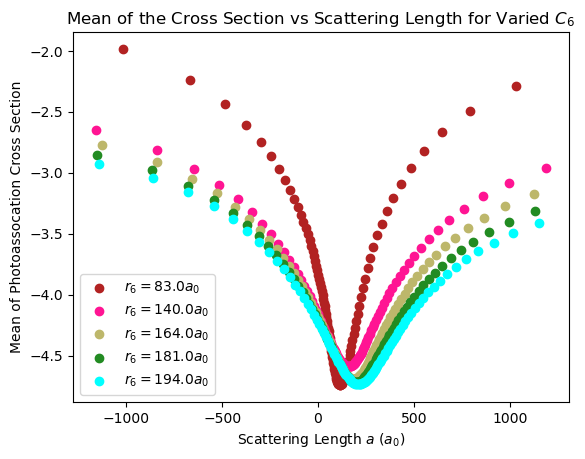

In [255]:
plt.scatter(a_sl1, a_mean1, color = 'firebrick', label = f'$r_6={round(0.5*r6_1,0)}a_0$')
plt.scatter(a_sl2, a_mean2, color = 'deeppink', label = f'$r_6={round(0.5*r6_2,0)}a_0$')
plt.scatter(a_sl3, a_mean3, color = 'darkkhaki', label = f'$r_6={round(0.5*r6_3,0)}a_0$')
plt.scatter(a_sl4, a_mean4, color = 'forestgreen', label = f'$r_6={round(0.5*r6_4,0)}a_0$')
plt.scatter(a_sl5, a_mean5, color = 'aqua', label = f'$r_6={round(0.5*r6_5,0)}a_0$')

plt.ylabel('Mean of Photoassocation Cross Section')
plt.xlabel('Scattering Length $a$ ($a_0$)')
plt.title('Mean of the Cross Section vs Scattering Length for Varied $C_6$')
plt.legend(loc='lower left')

plt.savefig('Homerun.png', bbox_inches='tight')

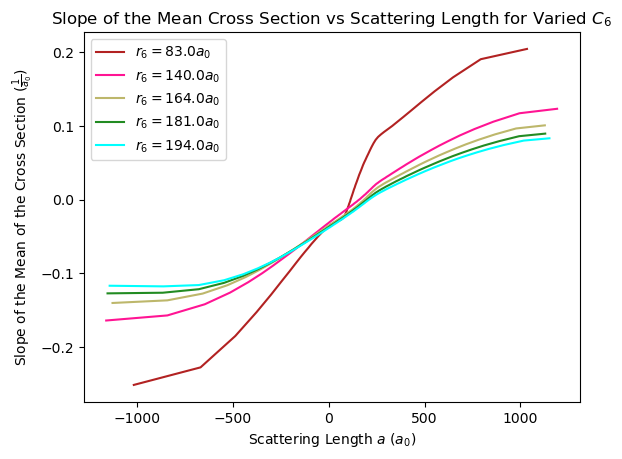

In [253]:
plt.plot(a_sl1, np.gradient(a_mean1), color = 'firebrick', label = f'$r_6={round(0.5*r6_1,0)}a_0$')
plt.plot(a_sl2, np.gradient(a_mean2), color = 'deeppink', label = f'$r_6={round(0.5*r6_2,0)}a_0$')
plt.plot(a_sl3, np.gradient(a_mean3), color = 'darkkhaki', label = f'$r_6={round(0.5*r6_3,0)}a_0$')
plt.plot(a_sl4, np.gradient(a_mean4), color = 'forestgreen', label = f'$r_6={round(0.5*r6_4,0)}a_0$')
plt.plot(a_sl5, np.gradient(a_mean5), color = 'aqua', label = f'$r_6={round(0.5*r6_5,0)}a_0$')

plt.ylabel('Slope of the Mean of the Cross Section ($\\frac{1}{a_0}$)')
plt.xlabel('Scattering Length $a$ ($a_0$)')
plt.title('Slope of the Mean Cross Section vs Scattering Length for Varied $C_6$')
plt.legend(loc='upper left')

plt.savefig('slope.png', bbox_inches='tight')

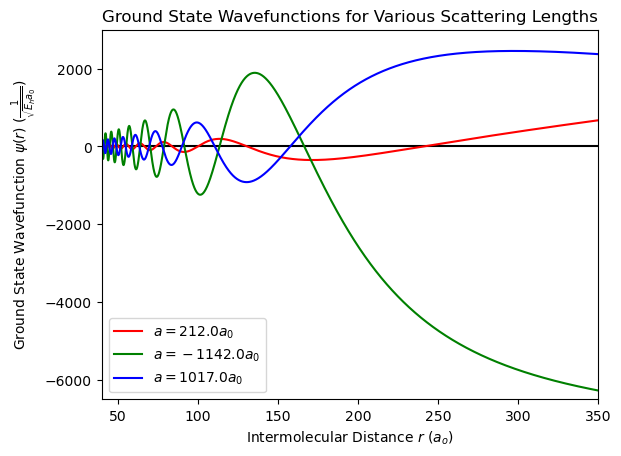

In [241]:
plt.hlines(0,0, R_grids_D5[0][-1], color = 'black')

plt.plot(R_grids_D5[0], psi_D5[min_a], label = f"$a={a_sl5[min_a]}a_0$", color = 'red', linestyle = 'solid') 
#plt.plot(R_grid, VLJ*H_to_K, color = 'purple', label = '$V1$, $C_6=6600 E_h a_0^6$', linestyle = 'dashed')

plt.plot(R_grids_D5[0], psi_D5[max_a], label = f"$a={a_sl5[max_a]}a_0$", color = 'green', linestyle = 'solid') 

plt.plot(R_grids_D5[0], psi_D5[pos_a], label = f"$a={a_sl5[pos_a]}a_0$", color = 'blue', linestyle = 'solid') 


plt.ylim(-6500,3000)
plt.xlim(40,350)


#plt.ylim(-10000,10000)
#plt.xlim(30,1300)

plt.ylabel('Ground State Wavefunction $\\psi(r)$ ($\\frac{1}{\\sqrt{E_h a_0}}$)')
plt.xlabel('Intermolecular Distance $r$ $(a_o)$')
plt.title('Ground State Wavefunctions for Various Scattering Lengths')
plt.legend(loc='lower left')

plt.savefig('final_SR.png', bbox_inches='tight')

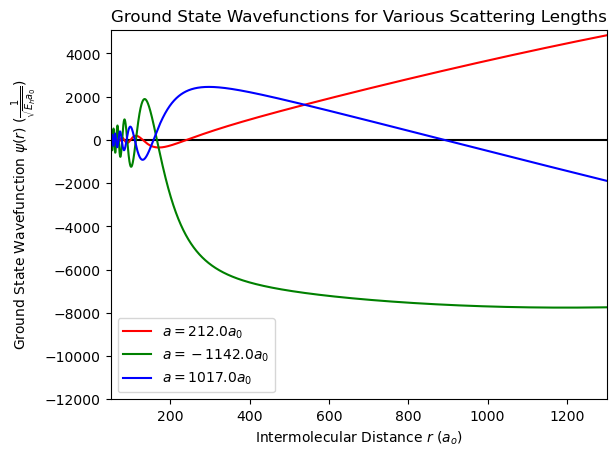

In [249]:
plt.hlines(0,0, R_grids_D5[0][-1], color = 'black')

plt.plot(R_grids_D5[0], psi_D5[min_a], label = f"$a={a_sl5[min_a]}a_0$", color = 'red', linestyle = 'solid') 
#plt.plot(R_grid, VLJ*H_to_K, color = 'purple', label = '$V1$, $C_6=6600 E_h a_0^6$', linestyle = 'dashed')

plt.plot(R_grids_D5[0], psi_D5[max_a], label = f"$a={a_sl5[max_a]}a_0$", color = 'green', linestyle = 'solid') 

plt.plot(R_grids_D5[0], psi_D5[pos_a], label = f"$a={a_sl5[pos_a]}a_0$", color = 'blue', linestyle = 'solid') 


plt.ylim(-12000,5100)
plt.xlim(50,R2)


#plt.ylim(-10000,10000)
#plt.xlim(30,1300)

plt.ylabel('Ground State Wavefunction $\\psi(r)$ ($\\frac{1}{\\sqrt{E_h a_0}}$)')
plt.xlabel('Intermolecular Distance $r$ $(a_o)$')
plt.title('Ground State Wavefunctions for Various Scattering Lengths')
plt.legend(loc='lower left')

plt.savefig('final_LR.png', bbox_inches='tight')